In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")

✅ Librerías importadas correctamente
   pandas   2.2.2
   numpy    1.26.4
   seaborn  0.13.2


In [2]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────────────────────
SQL_QUERY = """
SELECT
    nombre,
    inteligencia,
    fuerza,
    velocidad,
    durabilidad,
    combate,
    promedio_poder,
    ranking,
    CASE
        WHEN promedio_poder >= 70 THEN 1
        ELSE 0
    END AS es_poderoso
FROM superheroes
ORDER BY ranking, nombre;
"""

with engine.connect() as conn:
    df_heroes = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_heroes.shape[0]:,} filas × {df_heroes.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_heroes.columns.tolist()}")

print(f"\nBalance de la variable objetivo:")
bal = df_heroes['es_poderoso'].value_counts()
pct = df_heroes['es_poderoso'].value_counts(normalize=True) * 100

print(f"   Superhéroe poderoso    (1): {bal.get(1, 0):,} ({pct.get(1, 0):.1f}%)")
print(f"   Superhéroe no poderoso (0): {bal.get(0, 0):,} ({pct.get(0, 0):.1f}%)")

df_heroes.head()

✅ Datos cargados: 731 filas × 9 columnas

Columnas disponibles:
['nombre', 'inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'combate', 'promedio_poder', 'ranking', 'es_poderoso']

Balance de la variable objetivo:
   Superhéroe poderoso    (1): 121 (16.6%)
   Superhéroe no poderoso (0): 610 (83.4%)


,nombre,inteligencia,fuerza,velocidad,durabilidad,combate,promedio_poder,ranking,es_poderoso
0,Man of Miracles,100,100,100,100,100,100.00,1.0,1
1,One-Above-All,100,100,100,100,100,100.00,1.0,1
2,General Zod,94,100,96,100,95,97.50,3.0,1
3,Beyonder,100,100,100,100,84,97.33,4.0,1
4,Superboy-Prime,94,100,100,100,85,96.50,5.0,1


In [3]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(df_heroes.dtypes.to_frame('dtype').join(
    df_heroes.isnull().sum().to_frame('nulos')
))

# Balance de clases
balance = df_heroes['es_poderoso'].value_counts()
pct = df_heroes['es_poderoso'].value_counts(normalize=True) * 100

print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Superhéroe poderoso    (1): {balance.get(1, 0):>5,} ({pct.get(1, 0):.1f}%)")
print(f"   Superhéroe no poderoso (0): {balance.get(0, 0):>5,} ({pct.get(0, 0):.1f}%)")

print(f"\n🏆 Primeros registros ordenados por ranking:")
print(
    df_heroes[['nombre', 'promedio_poder', 'ranking', 'es_poderoso']]
    .head(10)
    .to_string(index=False)
)

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                  dtype  nulos
nombre           object      0
inteligencia      int64      0
fuerza            int64      0
velocidad         int64      0
durabilidad       int64      0
combate           int64      0
promedio_poder  float64      0
ranking         float64      0
es_poderoso       int64      0

🎯 Balance de la variable objetivo:
   Superhéroe poderoso    (1):   121 (16.6%)
   Superhéroe no poderoso (0):   610 (83.4%)

🏆 Primeros registros ordenados por ranking:
           nombre  promedio_poder  ranking  es_poderoso
  Man of Miracles          100.00      1.0            1
    One-Above-All          100.00      1.0            1
      General Zod           97.50      3.0            1
         Beyonder           97.33      4.0            1
   Superboy-Prime           96.50      5.0            1
         Superman           96.50      5.0            1
      Steppenwolf           96.17      7.0            1
Martian Manhu

In [5]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────────────────────
df = df_heroes.copy()

# 4.1 Variables predictoras del proyecto de superhéroes
FEATURES = [
    'inteligencia',
    'fuerza',
    'velocidad',
    'durabilidad',
    'combate'
]

# 4.2 Relleno de nulos con mediana en numéricas
for col in FEATURES:
    df[col] = df[col].fillna(df[col].median())

# 4.3 Columnas a escalar
scale_cols = FEATURES

# 4.4 Definir X_raw e y
X_raw = df[FEATURES]
y = df['es_poderoso']

# 4.5 Escalar
scaler = StandardScaler()
X_scaled = X_raw.copy()
X_scaled[scale_cols] = scaler.fit_transform(X_raw[scale_cols])

print(f"✅ Preprocesamiento completado")
print(f"   Shape X: {X_scaled.shape}")
print(f"   Columnas finales: {X_scaled.columns.tolist()}")
print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")

✅ Preprocesamiento completado
   Shape X: (731, 5)
   Columnas finales: ['inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'combate']

   Clases en y → 0: 610  |  1: 121


In [6]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split"):
    """
    Entrena LogisticRegression con un split train/test y devuelve
    un dict con métricas + datos para curva ROC.
    
    Nota: class_weight='balanced' compensa un posible desbalance
    entre superhéroes poderosos y no poderosos.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=random_state,
        class_weight='balanced'
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]   # probabilidad clase 1

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    metricas = {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }

    return metricas

print("✅ Función `entrenar_evaluar` definida correctamente")
print("   · LogisticRegression con class_weight='balanced'")

✅ Función `entrenar_evaluar` definida correctamente
   · LogisticRegression con class_weight='balanced'


In [7]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X_scaled, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X_scaled, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X_scaled, y, test_size=0.30, nombre="Split 70/30"),
]

print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA':^65}")
print("=" * 65)

header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)

for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )

print("=" * 65)

       MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA       
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20       584      147  0.9660  0.8276  1.0000  0.9057  0.9990
Split 60/40       438      293  0.9727  0.8571  1.0000  0.9231  0.9990
Split 70/30       511      220  0.9636  0.8182  1.0000  0.9000  0.9992


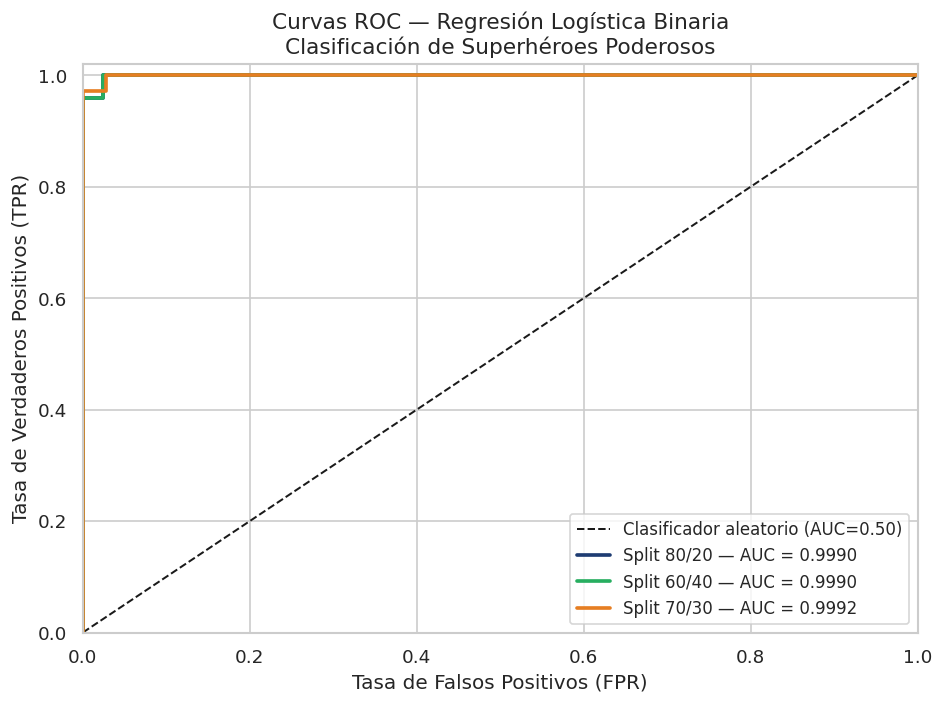

✅ Curvas ROC guardadas en data/graficas/roc_logistica_superheroes.png


In [8]:
# ── CELDA 7: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(r['fpr'], r['tpr'], color=color, lw=2.2, label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}")

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Regresión Logística Binaria\nClasificación de Superhéroes Poderosos', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../data/graficas/roc_logistica_superheroes.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Curvas ROC guardadas en data/graficas/roc_logistica_superheroes.png")

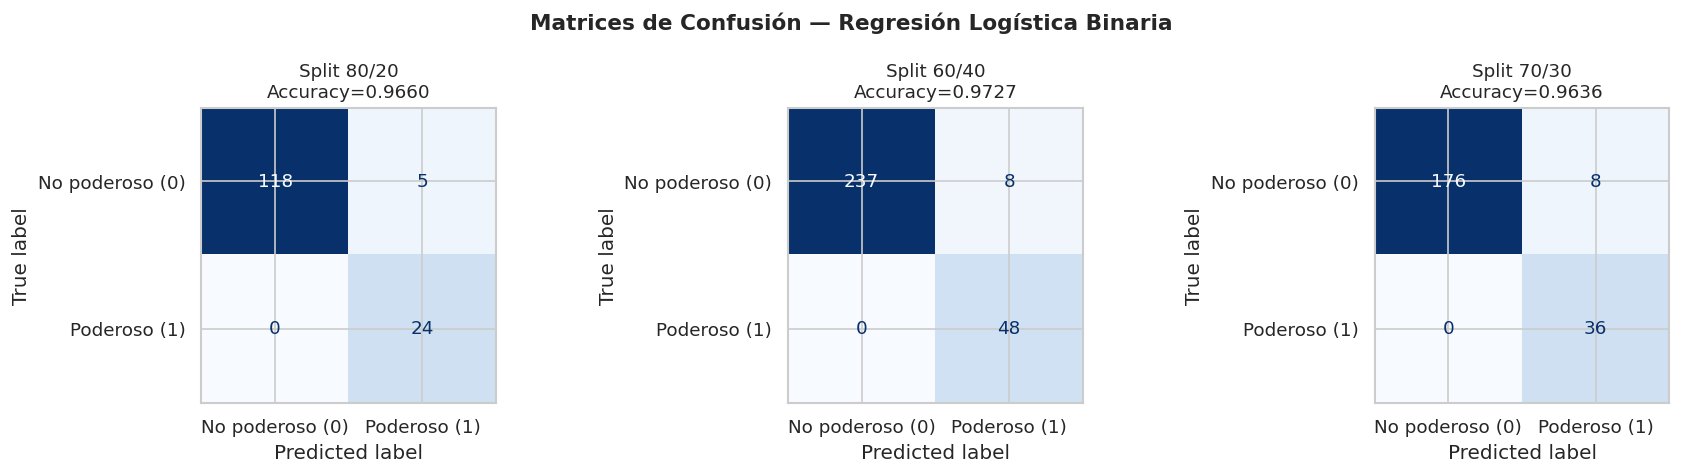

✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_superheroes.png


In [9]:
# ── CELDA 8: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Regresión Logística Binaria', fontsize=13, fontweight='bold')

for ax, r, color in zip(axes, resultados, COLORS):
    cm = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No poderoso (0)', 'Poderoso (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig('../data/graficas/confusion_logistica_superheroes.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_superheroes.png")

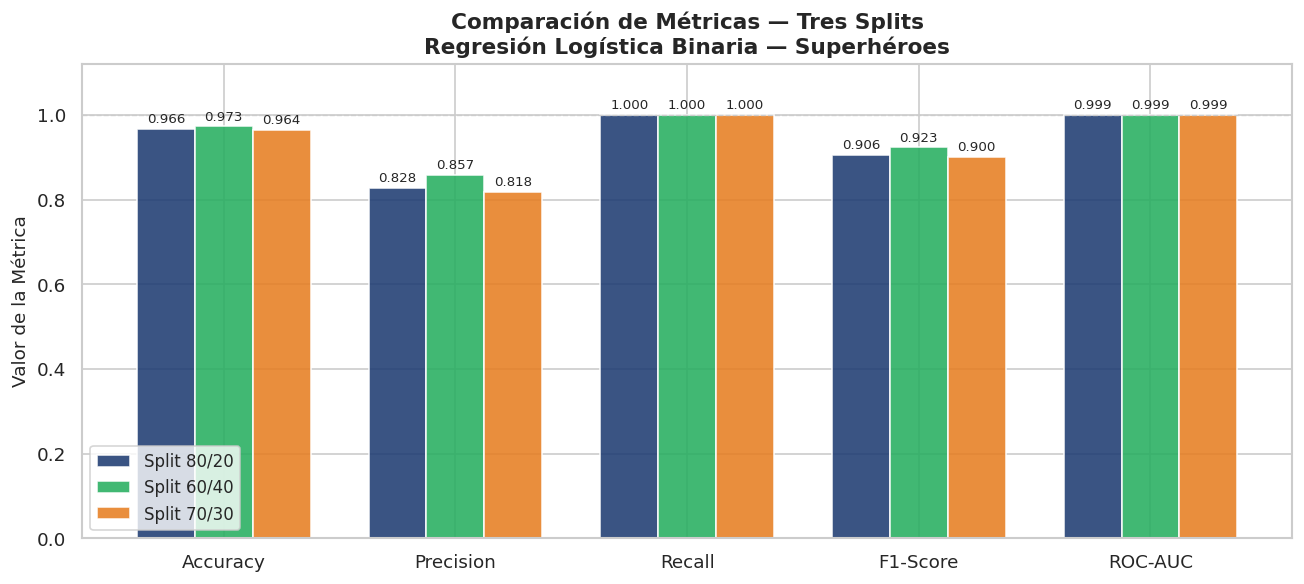

✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_logistica_superheroes.png


In [10]:
# ── CELDA 9: Gráfico comparativo de métricas ─────────────────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nRegresión Logística Binaria — Superhéroes', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../data/graficas/metricas_comparativas_logistica_superheroes.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_logistica_superheroes.png")

In [11]:
# ── CELDA 11: DataFrame resumen de métricas ───────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'], 4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'], 4),
    'F1-Score'       : round(r['f1'], 4),
    'ROC-AUC'        : round(r['roc_auc'], 4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS':^65}")
print("=" * 65)

display(
    resumen.style
    .background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption('Regresión Logística Binaria — Clasificación: Superhéroe Poderoso / No Poderoso')
)

                     TABLA FINAL DE MÉTRICAS                     


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,584,147,0.9660,0.8276,1.0000,0.9057,0.9990
Split 60/40,438,293,0.9727,0.8571,1.0000,0.9231,0.9990
Split 70/30,511,220,0.9636,0.8182,1.0000,0.9000,0.9992


In [13]:
# ── CELDA 12: Ajuste del umbral de clasificación ─────────────────────────────
# ── PASO SUGERIDO: Ajustar el umbral de clasificación ────────────────────────

modelo_ref = resultados[0]['modelo']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)
y_prob = modelo_ref.predict_proba(X_test)[:, 1]
umbral = 0.30
y_pred_umbral = (y_prob >= umbral).astype(int)

acc = accuracy_score(y_test, y_pred_umbral)
prec = precision_score(y_test, y_pred_umbral, zero_division=0)
rec = recall_score(y_test, y_pred_umbral, zero_division=0)
f1 = f1_score(y_test, y_pred_umbral, zero_division=0)

print("=" * 60)
print("AJUSTE DE UMBRAL DE CLASIFICACIÓN")
print("=" * 60)
print(f"Umbral utilizado : {umbral}")
print(f"Accuracy          : {acc:.4f}")
print(f"Precision         : {prec:.4f}")
print(f"Recall            : {rec:.4f}")
print(f"F1-Score          : {f1:.4f}")
print("=" * 60)

AJUSTE DE UMBRAL DE CLASIFICACIÓN
Umbral utilizado : 0.3
Accuracy          : 0.9184
Precision         : 0.6667
Recall            : 1.0000
F1-Score          : 0.8000


In [14]:
# ── CELDA 13: RandomForestClassifier ─────────────────────────────────────────
# ── PASO SUGERIDO: Explorar modelos más complejos ────────────────────────────

from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)

modelo_rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=" * 60)
print("RANDOM FOREST CLASSIFIER")
print("=" * 60)
print(f"Accuracy  : {acc_rf:.4f}")
print(f"Precision : {prec_rf:.4f}")
print(f"Recall    : {rec_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {auc_rf:.4f}")
print("=" * 60)

RANDOM FOREST CLASSIFIER
Accuracy  : 0.9524
Precision : 0.8148
Recall    : 0.9167
F1-Score  : 0.8627
ROC-AUC   : 0.9925


In [15]:
# ── CELDA 14: GradientBoostingClassifier ─────────────────────────────────────
# ── PASO SUGERIDO: Explorar modelos más complejos ────────────────────────────

from sklearn.ensemble import GradientBoostingClassifier

modelo_gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
modelo_gb.fit(X_train, y_train)

y_pred_gb = modelo_gb.predict(X_test)
y_prob_gb = modelo_gb.predict_proba(X_test)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("=" * 60)
print("GRADIENT BOOSTING CLASSIFIER")
print("=" * 60)
print(f"Accuracy  : {acc_gb:.4f}")
print(f"Precision : {prec_gb:.4f}")
print(f"Recall    : {rec_gb:.4f}")
print(f"F1-Score  : {f1_gb:.4f}")
print(f"ROC-AUC   : {auc_gb:.4f}")
print("=" * 60)

GRADIENT BOOSTING CLASSIFIER
Accuracy  : 0.9592
Precision : 0.8462
Recall    : 0.9167
F1-Score  : 0.8800
ROC-AUC   : 0.9946


In [16]:
# ── CELDA 15: Validación cruzada k-fold ──────────────────────────────────────
# ── PASO SUGERIDO: Aplicar validación cruzada (k-fold) ───────────────────────

from sklearn.model_selection import cross_val_score

modelo_cv = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

scores = cross_val_score(modelo_cv, X_scaled, y, cv=5, scoring='f1')

print("=" * 60)
print("VALIDACIÓN CRUZADA K-FOLD")
print("=" * 60)
print(f"F1-Score por fold:")
print(scores)
print(f"\nF1-Score promedio : {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")
print("=" * 60)

VALIDACIÓN CRUZADA K-FOLD
F1-Score por fold:
[0.41322314 1.         1.         1.         0.82926829]

F1-Score promedio : 0.8485
Desviación estándar: 0.2275
